In [ ]:
#x = 11
#https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition

wyekstrahować zestaw cech (kształt, ?
dla kilku owoców (jabłko, banan, ananas) (2-3)
1 zdjecie, wyznaczymy dla jabłka, wtedy wziąć reszte zdjęć i dla każdego z tych zdjęc wyekstrahować cechy

to samo dla ananasów, bananów etc

ta sama cecha, np długość

potem potworzyć wykresy dla każdego owocu



In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

print("Path to dataset files:", path)

100%|██████████| 1.98G/1.98G [00:21<00:00, 97.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8


In [21]:
path = "../fruit-and-vegetable-image-recognition/versions/8"

In [ ]:
#!pip install pandas seaborn matplotlib

  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl (11.0 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/4 [pytz]
   ---------- ----------------------------- 1/4 [tzdata]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 

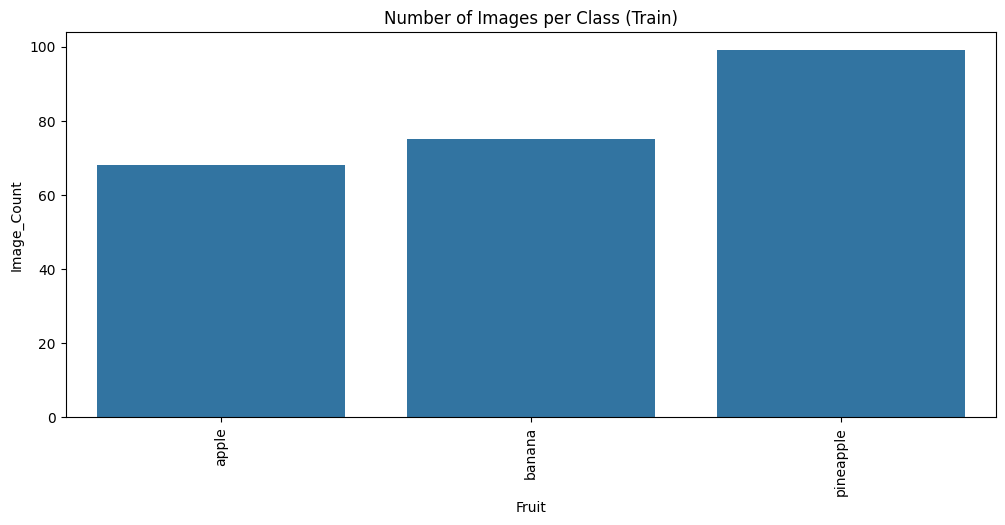

In [27]:
import pandas as pd
import seaborn
import matplotlib.pyplot as plt
import os

fruits = ["apple", "banana", "pineapple"]
image_count = {}

for fruit in fruits:
    fruit_path = os.path.join(path + '/train', fruit)
    image_count[fruit] = len(os.listdir(fruit_path))

df = pd.DataFrame(image_count.items(), columns=["Fruit", "Image_Count"])

plt.figure(figsize=(12,5))
seaborn.barplot(x="Fruit", y="Image_Count", data=df)
plt.xticks(rotation=90)
plt.title("Number of Images per Class (Train)")
plt.show()

In [28]:
import cv2
import matplotlib.pyplot as plt

def segment_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("Failed to load image:", image_path)
        return

    # Skalowanie - ujednolicenie rozdzielczosci
    image = cv2.resize(image, (256, 256))
    plt.imshow(image)

    # Odszumianie - filtr medianowy - zastępuje każdy piksel medianą wartości pikseli z jego najbliższego otoczenia (5x5).
    image = cv2.medianBlur(image, 5)
    plt.imshow(image)

    # konwersja na HSV
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    plt.imshow(hsv_image)


In [29]:
import cv2

def BGR2RGB(image):
  return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

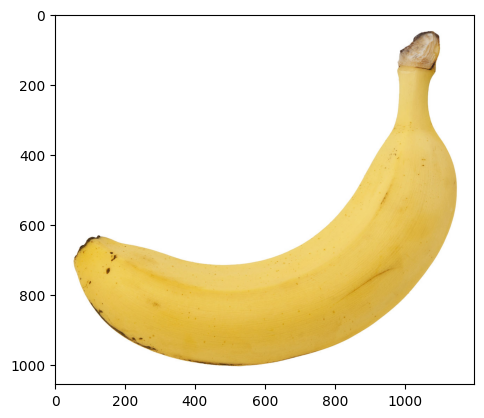

In [30]:
import matplotlib.pyplot as plt
img = cv2.imread(path + '/train/banana/Image_3.jpg')
if img is None:
    print("Failed to load image:", img)

# matplotlib potrzebuje RGB, cv2 podaje BGR
plt.imshow(BGR2RGB(img))

In [ ]:
# Skalowanie - ujednolicenie rozdzielczosci
# img = cv2.resize(img, (256, 256))
# plt.imshow(BGR2RGB(img))

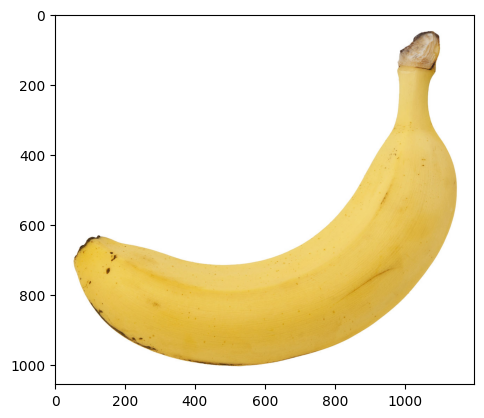

In [31]:
# Odszumianie - filtr medianowy - zastępuje każdy piksel medianą wartości pikseli z jego najbliższego otoczenia (5x5).
blurred_img = cv2.medianBlur(img, 5)
plt.imshow(BGR2RGB(img))

hsv jest lepsze dla klasyfikacji, bardziej odporne na zmiany oświetlenia

In [32]:
# konwersja na HSV
hsv_img = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2HSV)


In [33]:
hist = cv2.calcHist([img], [0, 1], None, [50, 50], [0, 180, 0, 256])
cv2.normalize(hist, hist)
hist.flatten()


array([0.00018978, 0.00011861, 0.00023722, ..., 0.        , 0.        ,
       0.        ], shape=(2500,), dtype=float32)

In [35]:
import numpy as np
# Progowanie nasycenia (S) i jasności (V)
# Przyjmujemy, że owoc jest nasycony i dość jasny.
# Wartości te mogą wymagać kalibracji!
lower_bound = np.array([0, 50, 50])  # Niska saturacja dla tła
upper_bound = np.array([179, 255, 255]) # Wysoka saturacja i jasność

mask = cv2.inRange(hsv_img, lower_bound, upper_bound)

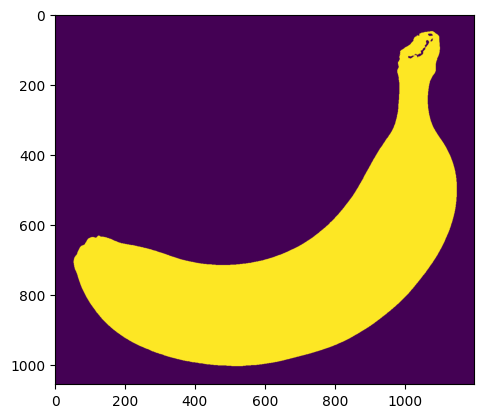

In [36]:
plt.imshow(mask)

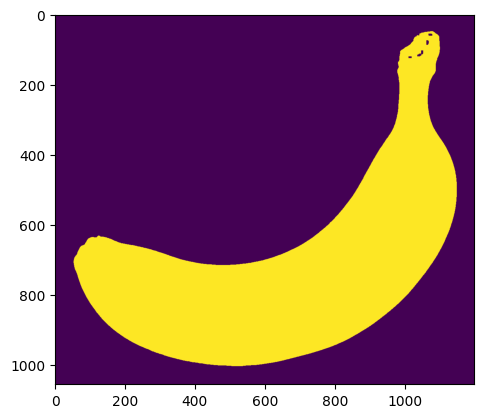

In [37]:
# Operacje morfologiczne - Zamknięcie (Dylacja, potem Erozja) - usunięcie dziur + wygładzenie maski
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
plt.imshow(mask)

In [38]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [39]:
largest_contour = max(contours, key=cv2.contourArea)

In [40]:
# Stworzenie maski tylko dla największego konturu
object_mask = np.zeros_like(mask)
# -1 - indeks konturu - wszystkie z listy rysujemy
# 255 - kolor
# -1 grubośc lini - kontur wypełniony
cv2.drawContours(object_mask, [largest_contour], -1, 255, -1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1057, 1200), dtype=uint8)

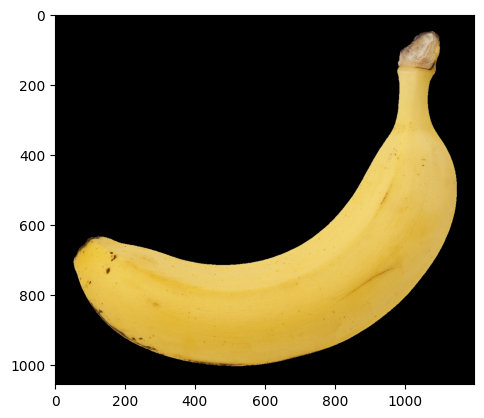

In [41]:
fruit_only = cv2.bitwise_and(img, img, mask=object_mask)
plt.imshow(BGR2RGB(fruit_only))

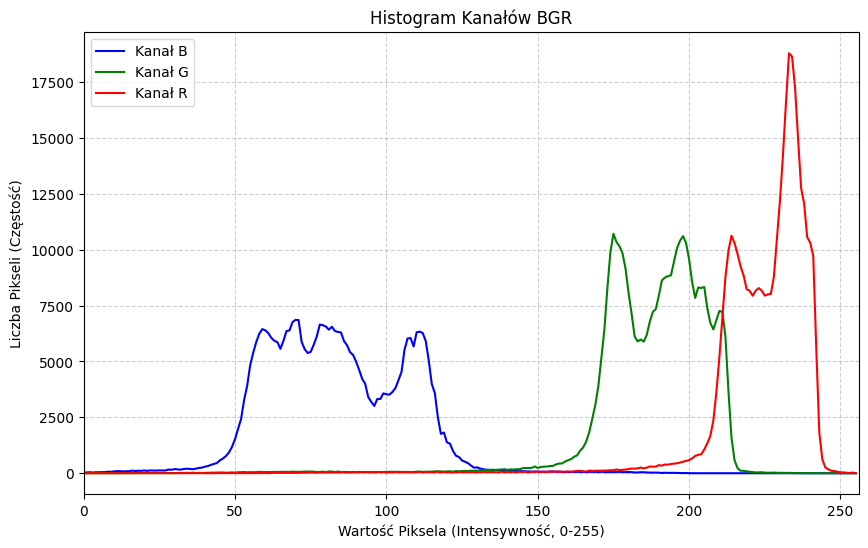

In [42]:
import numpy as np
# Ustalenie koloru dla każdego kanału na wykresie
color = ('b', 'g', 'r')

plt.figure(figsize=(10, 6))
plt.title('Histogram Kanałów BGR')
plt.xlabel('Wartość Piksela (Intensywność, 0-255)')
plt.ylabel('Liczba Pikseli (Częstość)')

# 2. Obliczanie i Wyświetlanie Histogramu dla Każdego Kanału

# Przechodzimy przez każdy kanał (indeksy 0=B, 1=G, 2=R)
for i, col in enumerate(color):

    # Obliczenie histogramu dla pojedynczego kanału
    # [img]: obraz wejściowy
    # [i]: indeks kanału (0, 1 lub 2)
    # None: brak maski
    # [256]: liczba kubełków (cały zakres 0-255)
    # [1, 256]: zakres wartości - bez 0, zeby wyciac czarny
    hist = cv2.calcHist([fruit_only], [i], None, [256], [1, 256])

    # Wyświetlenie histogramu
    # Podzielenie przez sumę, aby uzyskać znormalizowany (prawdopodobieństwo) wykres, choć nie jest to ścisła normalizacja sumy do 1
    plt.plot(hist, color=col, label=f'Kanał {col.upper()}')

    # Normalizacja Matplotlib dla lepszej czytelności skali, jeśli potrzeba
    plt.xlim([0, 256])

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Ekstrakcja cech

In [43]:
import pandas as pd
column_labels = [
    'H_Mean', 'S_Mean', 'V_Mean',
    'H_Std', 'S_Std', 'V_Std',
    'Aspect_Ratio', "Eccentricity", "Solidity", "Convexity"
]
df_features = pd.DataFrame(columns=column_labels)
df_features

,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity


In [44]:
h_channel = hsv_img[:, :, 0][object_mask == 255]
s_channel = hsv_img[:, :, 1][object_mask == 255]
v_channel = hsv_img[:, :, 2][object_mask == 255]

In [45]:
color_features = []

In [ ]:
# Średnia (Dominujący kolor/odcień)
color_features.extend([np.mean(h_channel), np.mean(s_channel), np.mean(v_channel)])
# Odchylenie standardowe (Rozrzut koloru/odcienia)
color_features.extend([np.std(h_channel), np.std(s_channel), np.std(v_channel)])


In [ ]:
print(color_features)

[np.float64(22.218270588516862), np.float64(159.56444008328745), np.float64(225.8503724268509), np.float64(1.236394576697297), np.float64(22.97654990251432), np.float64(15.856265382854076)]


Aspect ratio

In [ ]:
x, y, w, h = cv2.boundingRect(largest_contour)

In [ ]:
aspect_ratio = w / h if h != 0 else 0
aspect_ratio

1.1442006269592477

Ekscentryczność - jak bardzo kształt odbiega od koła w kierunku elipsy. Jest to stosunek osi eliptycznego dopasowania do konturu:

In [ ]:
from skimage.measure import label, regionprops

labeled_img = label(object_mask)
region = regionprops(labeled_img)[0]
eccentricity = region.eccentricity
print(eccentricity)




# # 1. Dopasowanie elipsy do konturu
# ellipse = cv2.fitEllipse(largest_contour)

# # 2. Oś długa i krótka (osi elipsy)
# (center, axes, orientation) = ellipse
# major_axis = max(axes)
# minor_axis = min(axes)

# # 3. Obliczenie Ekscentryczności
# if major_axis == 0:
#     eccentricity = 0
# else:
#     # Wzór OpenCV/standardowy
#     eccentricity = np.sqrt(1 - (minor_axis / major_axis)**2)

# eccentricity

0.8984783195062954


Solidity = area / convex_area

blisko 1 - obiekt zwiezly, wypukly
duzo mniejsze od 1 - obiekt z dziurami, wcieciami

In [ ]:
solidity = region.solidity
solidity

np.float64(0.6046384119291826)

Area, convex area

In [ ]:
area = region.area
area

np.float64(376047.0)

In [ ]:
convex_area = region.convex_area
convex_area

np.float64(621937.0)

Convexity - jak bardzo jest wypukly

In [ ]:
perimeter = cv2.arcLength(largest_contour, True)
convex_hull_perimeter = cv2.arcLength(cv2.convexHull(largest_contour), True)
convexity = convex_hull_perimeter / perimeter
convexity

0.8708872954227475

Wektor cech

In [ ]:
feature_vector = np.array(color_features + [aspect_ratio] + [eccentricity] + [solidity] + [convexity])
feature_vector

array([ 22.21827059, 159.56444008, 225.85037243,   1.23639458,
        22.9765499 ,  15.85626538,   1.14420063,   0.89847832,
         0.60463841,   0.8708873 ])

In [ ]:
# Utworzenie nowego wiersza jako obiektu Series
new_row = pd.Series(feature_vector, index=column_labels)

# Dodanie wiersza do DataFrame (używamy .to_frame().T, aby Series stało się wierszem)
df_features = pd.concat([df_features, new_row.to_frame().T], ignore_index=True)
df_features

/tmp/ipython-input-4279743308.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_features = pd.concat([df_features, new_row.to_frame().T], ignore_index=True)


,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity
0,22.218271,159.56444,225.850372,1.236395,22.97655,15.856265,1.144201,0.898478,0.604638,0.870887


In [46]:
import pandas as pd
column_labels = [
    'Class', 'H_Mean', 'S_Mean', 'V_Mean',
    'H_Std', 'S_Std', 'V_Std',
    'Aspect_Ratio', "Eccentricity", "Solidity", "Convexity"
]
df_train = pd.DataFrame(columns=column_labels)
df_train

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity


In [47]:
df_test = pd.DataFrame(columns=column_labels)
df_test

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity


In [ ]:
#!pip install scikit-image

  Using cached scipy-1.16.3-cp313-cp313-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.6/12.9 MB 12.0 MB/s eta 0:00:01
   ------------------------ --------------- 7.9/12.9 MB 24.5 MB/s eta 0:00:01
   ---------------------------------------- 12.9/12.9 MB 26.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 23.3 MB/s  0:00:00
Using cached scipy-1.16.3-cp313-cp313-win_amd64.whl (38.5 MB)

   ---------------------------------------- 0/6 [tifffile]
   ---------------------------------------- 0/6 [tifffile]
   ---------------------------------------- 0/6 [tifffile]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ ----------

In [53]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def extract_features(df_features, image_path, fruit):
    image = cv2.imread(image_path)
    if image is None:
        print("Failed to load image:", image_path)
        return

    # Skalowanie - ujednolicenie rozdzielczosci - NIE UZYWAĆ
    # image = cv2.resize(image, (256, 256))

    # Odszumianie - filtr medianowy - zastępuje każdy piksel medianą wartości pikseli z jego najbliższego otoczenia (5x5).
    image = cv2.medianBlur(image, 5)

    # konwersja na HSV
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Progowanie nasycenia (S) i jasności (V)
    # Przyjmujemy, że owoc jest nasycony i dość jasny.
    lower_bound = np.array([0, 50, 50])  # Niska saturacja dla tła
    upper_bound = np.array([179, 255, 255]) # Wysoka saturacja i jasność
    mask = cv2.inRange(hsv_image, lower_bound, upper_bound)

    # Operacje morfologiczne - Zamknięcie (Dylacja, potem Erozja) - usunięcie dziur + wygładzenie maski
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # znalezienie kontur
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_contour = max(contours, key=cv2.contourArea)

    # Stworzenie maski tylko dla największego konturu
    object_mask = np.zeros_like(mask)
    # -1 - indeks konturu - wszystkie z listy rysujemy
    # 255 - kolor
    # -1 grubośc lini - kontur wypełniony
    cv2.drawContours(object_mask, [largest_contour], -1, 255, -1)

    plt.show

    fruit_only = cv2.bitwise_and(image, image, mask=object_mask)

    # ekstrakcja cech
    h_channel = hsv_image[:, :, 0][object_mask == 255]
    s_channel = hsv_image[:, :, 1][object_mask == 255]
    v_channel = hsv_image[:, :, 2][object_mask == 255]

    color_features = []
    # Średnia (Dominujący kolor/odcień)
    color_features.extend([np.mean(h_channel), np.mean(s_channel), np.mean(v_channel)])
    # Odchylenie standardowe (Rozrzut koloru/odcienia)
    color_features.extend([np.std(h_channel), np.std(s_channel), np.std(v_channel)])

    # aspect ratio
    x, y, w, h = cv2.boundingRect(largest_contour)
    aspect_ratio = w / h if h != 0 else 0

    from skimage.measure import label, regionprops

    # eccentricity
    labeled_img = label(object_mask)
    region = regionprops(labeled_img)[0]
    eccentricity = region.eccentricity

    # solidity
    solidity = region.solidity

    # convexity
    perimeter = cv2.arcLength(largest_contour, True)
    convex_hull_perimeter = cv2.arcLength(cv2.convexHull(largest_contour), True)
    convexity = convex_hull_perimeter / perimeter

    # # 1. Dopasowanie elipsy do ksztaltu - potrzeba min. 5 punktow
    # if len(largest_contour) >= 5:
    #   ellipse = cv2.fitEllipse(largest_contour)
    #   # 2. Oś długa i krótka (osi elipsy)
    #   (center, axes, orientation) = ellipse
    #   #major_axis = 0
    #   minor_axis = min(axes)

    #   # # 3. Obliczenie Ekscentryczności
    #   # if major_axis == 0:
    #   #     eccentricity = 0
    #   # else:
    #   #     # Wzór OpenCV/standardowy
    #   #     eccentricity = np.sqrt(1 - (minor_axis / major_axis)**2)
    # else:
    #   eccentricity = 0

    # Wektor cech
    feature_vector = np.array([fruit] + color_features + [aspect_ratio] + [eccentricity] + [solidity] + [convexity])

    # Utworzenie nowego wiersza jako obiektu Series
    #new_row = pd.Series(feature_vector, index=column_labels)

    # Dodanie wiersza do DataFrame (używamy .to_frame().T, aby Series stało się wierszem)
    #df_features = pd.concat([df_features, new_row.to_frame().T], ignore_index=True)

    df_features.loc[len(df_features)] = feature_vector


In [49]:
fruits = ["apple", "banana", "pineapple"]

In [54]:
import os

# train
dirpath = path + '/train'
for fruit in fruits:
  for filename in os.listdir(dirpath + '/' + fruit):
    extract_features(df_train, dirpath + '/' + fruit + '/' + filename, fruit)


ModuleNotFoundError: No module named 'skimage'

In [27]:
df_train

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity
0,apple,15.079862974882568,168.28479477332573,142.64880517691398,24.581668240773215,29.84292087115386,33.28651977392905,1.0598885793871866,0.3035709575673298,0.9900985808193932,0.9017659072892173
1,apple,58.304173149564306,119.10612705450923,117.81792276940571,44.918258726065865,60.762816786927544,44.23483792643972,1.5,0.7446844304347646,0.947715237217035,0.5407026911505509
2,apple,154.13816664341678,193.41739576637312,179.70809992912876,37.19253413835723,54.570331093248065,44.975449465916725,1.2655190401669274,0.6570105311595487,0.8496158944104947,0.48005034181727413
3,apple,37.179642876886504,153.8277892641937,178.15144673558515,4.76314164857232,50.64713931307225,47.63962373030067,1.0799086757990868,0.6760511779450078,0.713719802341162,0.5335665367871726
4,apple,15.658119255490652,184.26745074639365,196.5428469735988,6.915309541740957,51.52084752579529,28.519990782733256,0.7764900662251656,0.47466073968419276,0.9322110810217376,0.8604952272349629
...,...,...,...,...,...,...,...,...,...,...,...
237,pineapple,29.025890623765765,179.59893625424576,173.05453803417677,14.616224723409724,44.43722005436257,52.82298003385873,0.43912678421494544,0.943533660732068,0.7110734158634583,0.40868089981002453
238,pineapple,20.644112934381273,133.7677615787507,137.5319052926908,11.302314767687538,56.380441852490804,37.11814019829503,0.43178807947019865,0.9269072282466851,0.7494983273623115,0.3760519566103967
239,pineapple,27.768429138740427,187.435119043988,189.87612863251698,15.929525567961507,58.66824825821195,65.5063107243578,0.449438202247191,0.931773115961326,0.745313686354564,0.4379891947704628
240,pineapple,14.703206213864393,135.18542311510834,167.86658030400366,10.191819154129332,45.65386285853168,51.933189554467766,1.9,0.8506592836645059,0.9990744055906963,0.971631413052342


In [22]:
#test
dirpath = path + '/test'
for fruit in fruits:
  for filename in os.listdir(dirpath + '/' + fruit):
    extract_features(df_test, dirpath + '/' + fruit + '/' + filename, fruit)

In [23]:
df_test

,Class,H_Mean,S_Mean,V_Mean,H_Std,S_Std,V_Std,Aspect_Ratio,Eccentricity,Solidity,Convexity
0,apple,63.26700137362197,157.2973608740804,161.89779163851648,79.35847048300367,53.658620774706655,46.93129671190414,0.8621867881548975,0.5933041908826108,0.9308165541153066,0.7140259917298658
1,apple,157.09922605848377,145.56820485034567,149.88346895705195,55.145265284741384,52.00075215699468,50.95635175374255,1.835575485799701,0.8815539484269911,0.8267072201292641,0.5495078477094937
2,apple,153.10695159009538,194.7282546559557,189.082035833559,50.33755279575168,60.856567813314655,42.162299739604215,0.9226190476190477,0.6866873300843934,0.8715786989386182,0.6224610675467126
3,apple,8.806256778886029,224.69636970715212,135.25823278187116,9.824612461190064,40.34896693779375,56.18030286953072,1.499267935578331,0.809152052730126,0.7395437751647145,0.49291583795020877
4,apple,15.034666560008533,145.0000106658134,137.53064554835612,21.54200025171343,44.91538602729649,49.91109789108182,1.7777777777777777,0.8218613034021806,0.9024266115147643,0.6333851203034429
5,apple,63.26700137362197,157.2973608740804,161.89779163851648,79.35847048300367,53.658620774706655,46.93129671190414,0.8621867881548975,0.5933041908826108,0.9308165541153066,0.7140259917298658
6,apple,104.32915629688586,132.04507106058682,193.11340205716428,7.179245556293873,27.245468447088843,25.718642950580353,1.5,0.7279757426728309,0.7352330164973497,0.3354555128169366
7,apple,155.904127610167,198.1958647523082,169.14970835811238,57.785788346950184,25.645640522847597,52.371516745689306,0.9577015163607342,0.3922917659893192,0.9637515631099437,0.8336846286074336
8,apple,68.68720665234261,138.2280484688556,147.47416715340648,62.05986460673311,47.35569961529947,67.9945491150499,1.4666666666666666,0.6416363631842547,0.8476097543725488,0.4713801842733973
9,apple,62.829323344879874,230.1030807005829,225.5891518161457,56.84073827560387,39.98075532903829,31.928006893682348,1.0868055555555556,0.36538429235225595,0.9154067296396405,0.9057693082805955


In [28]:
from sklearn.model_selection import train_test_split

X_train = df_train.drop('Class', axis=1)
y_train = df_train['Class']

X_test = df_test.drop('Class', axis=1)
y_test = df_test['Class']

In [29]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42, max_depth=19)
dtc.fit(X_train, y_train)

y_pred = dtc.predict(X_test)

Dokładność dtc: 0.8621


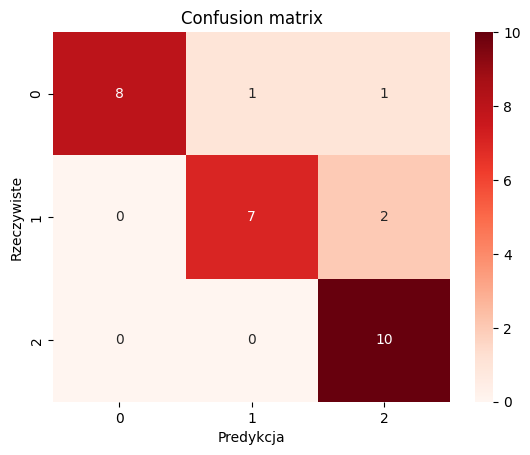

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print(f'Dokładność dtc: {dtc.score(X_test,y_test):.4}')

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion matrix")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.show()

In [36]:
import matplotlib.pyplot as plt

test_apple_path = '/content/image_2025-12-19_200627285.png'
img = cv2.imread(path + test_apple_path)
if img is None:
    print("Failed to load image:", img)

# matplotlib potrzebuje RGB, cv2 podaje BGR
plt.imshow(BGR2RGB(img))

Failed to load image: None


error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'
